In [2]:
from google.colab import drive
from IPython.display import clear_output
drive.mount('/content/drive')
!pip install -r '/content/drive/MyDrive/requirements.txt'
clear_output()

### 주요 지표 시각화

In [5]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches
import os
import pandas as pd

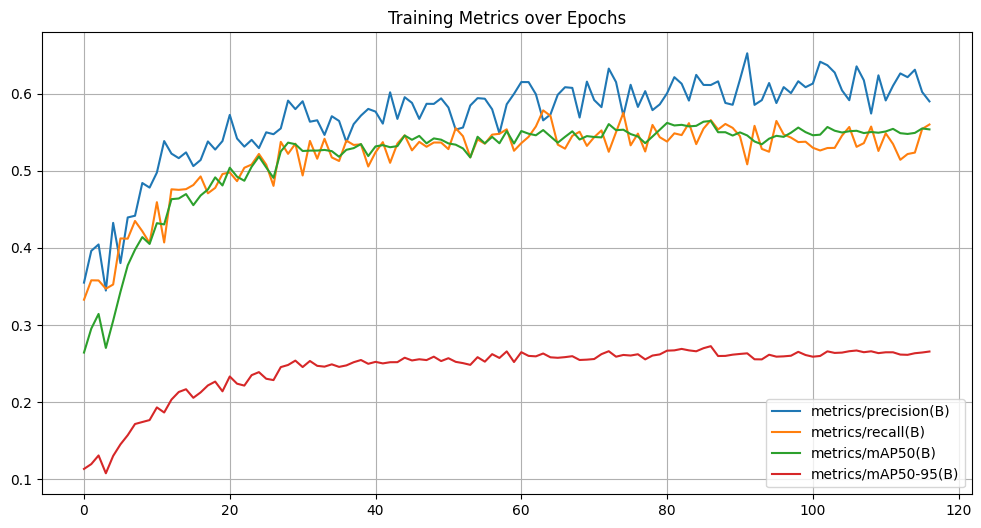

In [6]:
# 결과 파일 로드
log_path = '/content/drive/MyDrive/USC-Hackathon/project/rdm_v8m_150ep_augv6_optimized/results.csv'
df = pd.read_csv(log_path)

# 주요 지표 시각화
metrics = ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']
df[metrics].plot(figsize=(12, 6), title="Training Metrics over Epochs")
plt.grid()
plt.show()

### 예측 vs 정답 비교 시각화

In [7]:
# 모델 로드 및 예측
model = YOLO('/content/drive/MyDrive/USC-Hackathon/project/rdm_v8m_150ep_augv6_optimized/weights/best.pt')
results = model.predict(source='/content/drive/MyDrive/USC-Hackathon/project/images/val', conf=0.25, save=False)

# Define common road damage class names (you can modify based on your dataset)
class_names = {
    0: 'Pothole',
    1: 'Alligator Crack',
    2: 'Transverse Crack',
    3: 'Longitudinal Crack',
}

def load_ground_truth(label_path):
    bboxes = []
    if not os.path.exists(label_path):
        return bboxes

    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, w, h = map(float, parts)
                bboxes.append({'class_id': int(cls), 'x_center': xc, 'y_center': yc, 'width': w, 'height': h})
    return bboxes

# 예측 결과와 정답 바운딩 박스를 함께 시각화
for result in results[:6]:
    img_path = result.path
    img = Image.open(img_path)
    img_width, img_height = img.size
    base_name = os.path.splitext(os.path.basename(img_path))[0]
    label_path = f"/content/drive/MyDrive/USC-Hackathon/project/labels/val/{base_name}.txt"
    gt_boxes = load_ground_truth(label_path)

    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    ax.imshow(img)

    # 예측 박스 (빨강)
    for box in result.boxes:
        cls = int(box.cls[0].cpu())
        conf = float(box.conf[0].cpu())
        x_center, y_center, w, h = box.xywhn[0].cpu().numpy()

        x_min = (x_center - w / 2) * img_width
        y_min = (y_center - h / 2) * img_height
        box_w = w * img_width
        box_h = h * img_height

        ax.add_patch(patches.Rectangle((x_min, y_min), box_w, box_h,
                                       linewidth=2, edgecolor='red', facecolor='none'))
        ax.text(x_min, y_min - 10, f"P:{class_names.get(cls, cls)} {conf:.2f}",
                color='white', fontsize=10,
                bbox=dict(facecolor='red', alpha=0.5))

    # 정답 박스 (초록)
    for bbox in gt_boxes:
        cls = bbox['class_id']
        x_center = bbox['x_center']
        y_center = bbox['y_center']
        w = bbox['width']
        h = bbox['height']

        x_min = (x_center - w / 2) * img_width
        y_min = (y_center - h / 2) * img_height
        box_w = w * img_width
        box_h = h * img_height

        ax.add_patch(patches.Rectangle((x_min, y_min), box_w, box_h,
                                       linewidth=2, edgecolor='green', facecolor='none'))
        ax.text(x_min, y_min + box_h + 5, f"G:{class_names.get(cls, cls)}",
                color='white', fontsize=10,
                bbox=dict(facecolor='green', alpha=0.5))

    ax.set_title(f"{base_name} | RED: Prediction, GREEN: Ground Truth")
    ax.axis('off')
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

### 예측 실패 필터링

In [1]:
# 예측 실패: 예측된 박스 수 == 0
failed_results = [res for res in results if res.boxes is None or len(res.boxes) == 0]
print(f"❗ 예측 실패 샘플 수: {len(failed_results)/len(results)}")

# 일부 확인
for result in failed_results[:3]:
    img = Image.open(result.path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Prediction FAILED: {os.path.basename(result.path)}")
    plt.axis('off')
    plt.show()

NameError: name 'results' is not defined